In [25]:
#v. 20250121.1
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, optimize


input_dir = "./data/response-intensity/"
filename = "blue cone 4.txt"
x = []
y = []
with open(input_dir + filename, 'r', encoding='utf-8') as file:
    for line in file:
        try:
            xi, yi = (float('0' if num == '.' else num) for num in line.split())
        except ValueError:
            continue
        x.append(xi)
        y.append(yi)
x = np.array(x)
y = np.array(y)

x0 = 301.549
h = 1.020
R-squared = 0.992


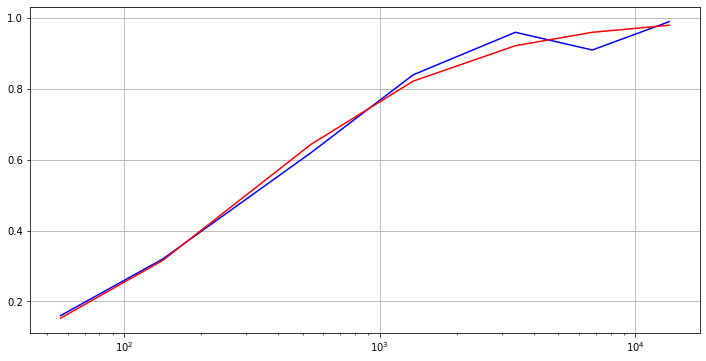

In [26]:
def func(x, x0, h):
    return pow(x, h) / (pow(x0, h) + pow(x, h))

popt, pcov = optimize.curve_fit(func, x, y, [x[0], 1])
x0 = popt[0]
h = popt[1]
rvalue = stats.linregress(func(x, x0, h), y).rvalue
print(f'x0 = {x0:.3f}')
print(f'h = {h:.3f}')
print(f'R-squared = {rvalue ** 2:.3f}')
fig, ax = plt.subplots()
ax.plot(x, y, 'b')
ax.plot(x, func(x, x0, h), 'r')
ax.set_xscale('log')
fig.set_figwidth(12)
fig.set_figheight(6)
ax.grid()